In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
df = pd.read_csv("../data/clean_reviews.csv")

In [3]:
X = df["processed_text"]
y = df["helpful_label"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# TF-IDF
vectorizer = TfidfVectorizer(max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [6]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# predict
y_pred = model.predict(X_test_tfidf)

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.963963963963964

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        51
           1       1.00      0.93      0.97        60

    accuracy                           0.96       111
   macro avg       0.96      0.97      0.96       111
weighted avg       0.97      0.96      0.96       111


Confusion Matrix:
[[51  0]
 [ 4 56]]


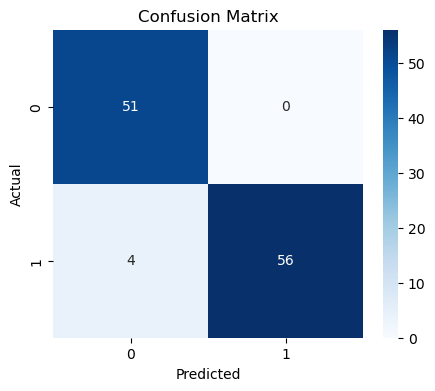

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [9]:
os.makedirs("../model", exist_ok=True)
joblib.dump(model, "../model/helpfulness_model.pkl")
joblib.dump(vectorizer, "../model/vectorizer.pkl")

['../model/vectorizer.pkl']